In [46]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt

plt.style.use("ggplot")

### Load Dataset

In [47]:
orders = pd.read_csv(
    "../../data/raw/olist-ecommerce-public-dataset/olist_orders_dataset.csv"
)

payments = pd.read_csv(
    "../../data/raw/olist-ecommerce-public-dataset/olist_order_payments_dataset.csv"
)

### View the dataset

In [48]:
orders.head(3)

,order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date
0,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2017-10-02 10:56:33,2017-10-02 11:07:15,2017-10-04 19:55:00,2017-10-10 21:25:13,2017-10-18 00:00:00
1,53cdb2fc8bc7dce0b6741e2150273451,b0830fb4747a6c6d20dea0b8c802d7ef,delivered,2018-07-24 20:41:37,2018-07-26 03:24:27,2018-07-26 14:31:00,2018-08-07 15:27:45,2018-08-13 00:00:00
2,47770eb9100c2d0c44946d9cf07ec65d,41ce2a54c0b03bf3443c3d931a367089,delivered,2018-08-08 08:38:49,2018-08-08 08:55:23,2018-08-08 13:50:00,2018-08-17 18:06:29,2018-09-04 00:00:00


In [49]:
payments.head(3)

,order_id,payment_sequential,payment_type,payment_installments,payment_value
0,b81ef226f3fe1789b1e8b2acac839d17,1,credit_card,8,99.33
1,a9810da82917af2d9aefd1278f1dcfa0,1,credit_card,1,24.39
2,25e8ea4e93396b6fa0d3dd708e76c1bd,1,credit_card,1,65.71


### Convert DateTime

In [50]:
orders["order_purchase_timestamp"] = pd.to_datetime(
    orders["order_purchase_timestamp"]
)

### Keep the "Delivered" Orders

In [51]:
orders = orders[
    orders["order_status"] == "delivered"
].copy()

In [52]:
orders["order_status"].value_counts()

order_status
delivered    96478
Name: count, dtype: int64

### Merge Payments

In [53]:
payment_summary = (payments.groupby("order_id")["payment_value"].sum().reset_index())

In [54]:
payment_summary["order_id"].duplicated().sum()

np.int64(0)

In [55]:
sales = orders.merge(
    payment_summary,
    on="order_id",
    how="left"
)

In [56]:
sales.head(3)

,order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date,payment_value
0,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2017-10-02 10:56:33,2017-10-02 11:07:15,2017-10-04 19:55:00,2017-10-10 21:25:13,2017-10-18 00:00:00,38.71
1,53cdb2fc8bc7dce0b6741e2150273451,b0830fb4747a6c6d20dea0b8c802d7ef,delivered,2018-07-24 20:41:37,2018-07-26 03:24:27,2018-07-26 14:31:00,2018-08-07 15:27:45,2018-08-13 00:00:00,141.46
2,47770eb9100c2d0c44946d9cf07ec65d,41ce2a54c0b03bf3443c3d931a367089,delivered,2018-08-08 08:38:49,2018-08-08 08:55:23,2018-08-08 13:50:00,2018-08-17 18:06:29,2018-09-04 00:00:00,179.12


### Checking missing value

In [57]:
sales.isna().sum()

order_id                          0
customer_id                       0
order_status                      0
order_purchase_timestamp          0
order_approved_at                14
order_delivered_carrier_date      2
order_delivered_customer_date     8
order_estimated_delivery_date     0
payment_value                     1
dtype: int64

In [58]:
sales[sales["payment_value"].isna()]

,order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date,payment_value
29811,bfbd0f9bdef84302105ad712db648a6c,86dc2ffce2dfff336de2f386a786e574,delivered,2016-09-15 12:16:38,2016-09-15 12:16:38,2016-11-07 17:11:53,2016-11-09 07:47:38,2016-10-04 00:00:00,NaN


In [59]:
sales = sales.dropna(subset=["payment_value"]).copy()

In [60]:
sales[sales["payment_value"].isna()]

,order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date,payment_value


In [61]:
print(sales["payment_value"].describe())

print(
    (sales["payment_value"] < 0).sum()
)

print(
    (sales["payment_value"] == 0).sum()
)

count    96477.000000
mean       159.856357
std        218.813144
min          9.590000
25%         61.880000
50%        105.280000
75%        176.330000
max      13664.080000
Name: payment_value, dtype: float64
0
0


## Create Weekly Sales

In [62]:
weekly_sales = (
    sales
    .set_index("order_purchase_timestamp")
    .resample("W")
    .agg(
        revenue=("payment_value", "sum"),
        orders=("order_id", "count")
    )
)

In [63]:
weekly_sales.head()

,revenue,orders
order_purchase_timestamp,,
2016-10-09,42669.98,231
2016-10-16,3896.73,34
2016-10-23,0.00,0
2016-10-30,0.00,0
2016-11-06,0.00,0


## Create Monthly Sales

In [64]:
monthly_sales = (
    sales
    .set_index("order_purchase_timestamp")
    .resample("ME")
    .agg(
        revenue=("payment_value", "sum"),
        orders=("order_id", "count")
    )
)

In [65]:
monthly_sales.head()

,revenue,orders
order_purchase_timestamp,,
2016-10-31,46566.71,265
2016-11-30,0.00,0
2016-12-31,19.62,1
2017-01-31,127545.67,750
2017-02-28,271298.65,1653


### Plot weekly revenue

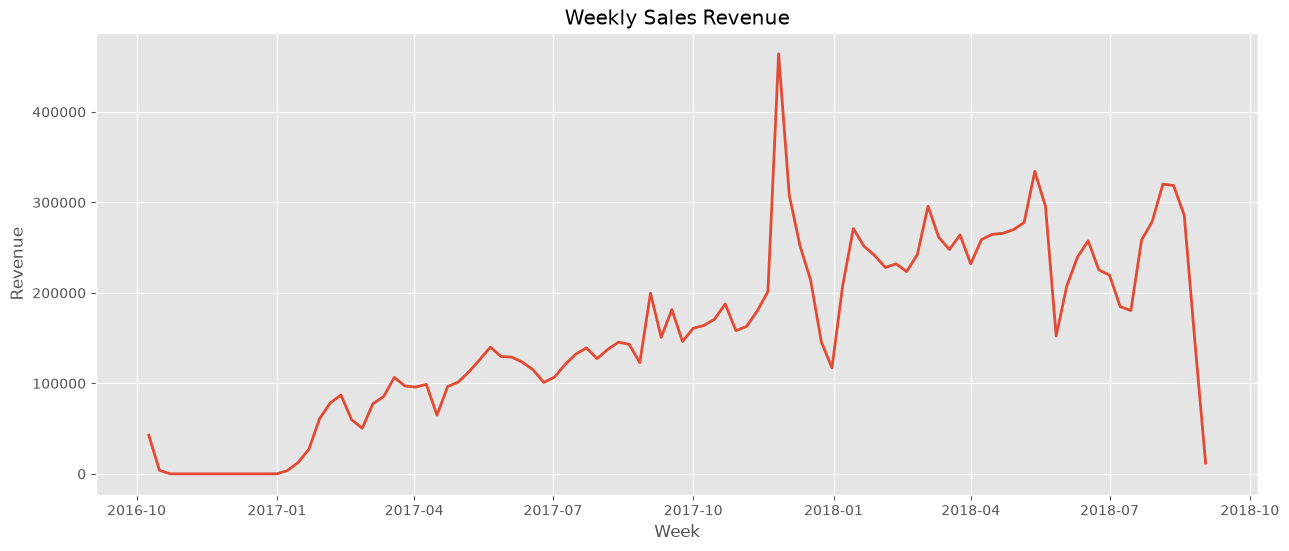

In [66]:
plt.figure(figsize=(15,6))

plt.plot(
    weekly_sales.index,
    weekly_sales["revenue"],
    linewidth=2
)

plt.title("Weekly Sales Revenue")
plt.xlabel("Week")
plt.ylabel("Revenue")

plt.grid(True)

plt.show()

### Plot monthly sales revenue

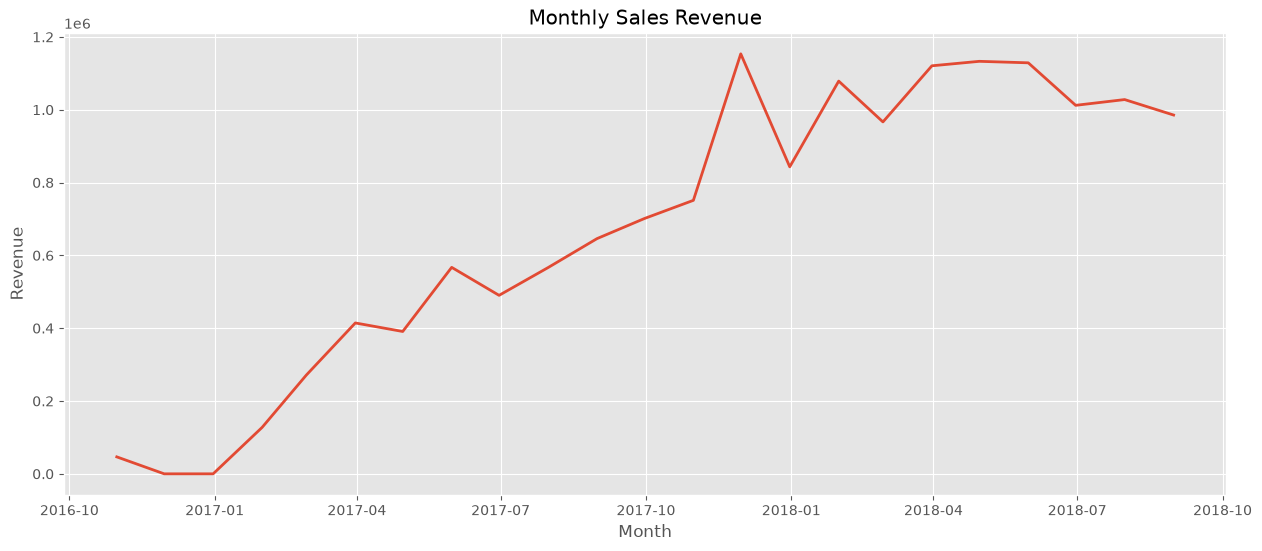

In [67]:
plt.figure(figsize=(15,6))

plt.plot(
    monthly_sales.index,
    monthly_sales["revenue"],
    linewidth=2
)

plt.title("Monthly Sales Revenue")
plt.xlabel("Month")
plt.ylabel("Revenue")

plt.grid(True)

plt.show()

### Weekly Order Count

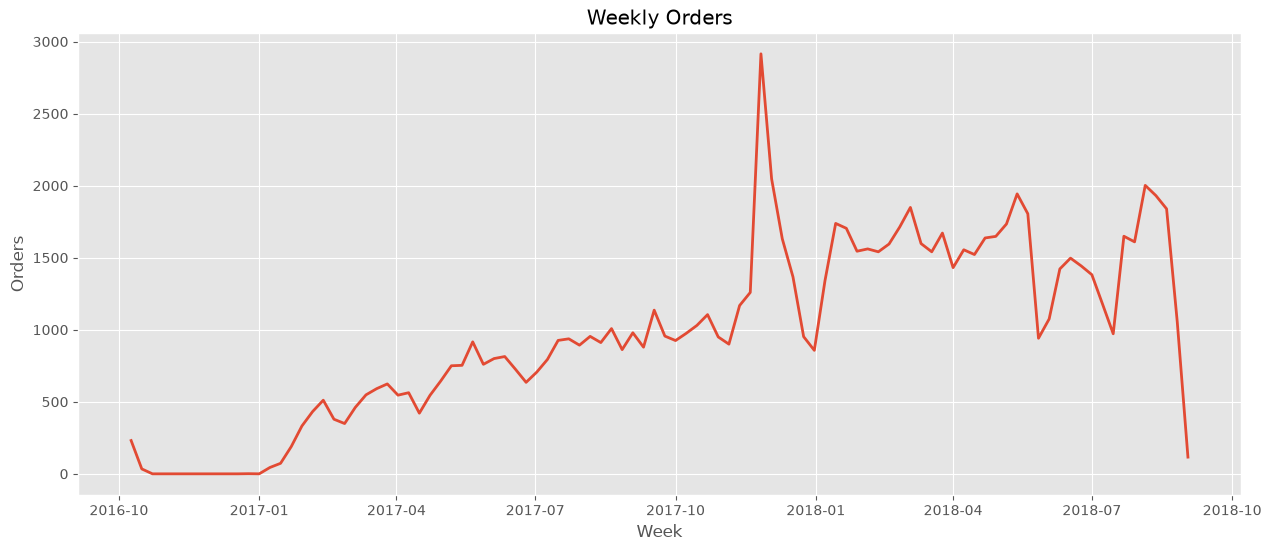

In [68]:
plt.figure(figsize=(15,6))

plt.plot(
    weekly_sales.index,
    weekly_sales["orders"],
    linewidth=2
)

plt.title("Weekly Orders")
plt.xlabel("Week")
plt.ylabel("Orders")

plt.grid(True)

plt.show()

### Monthly Order Count

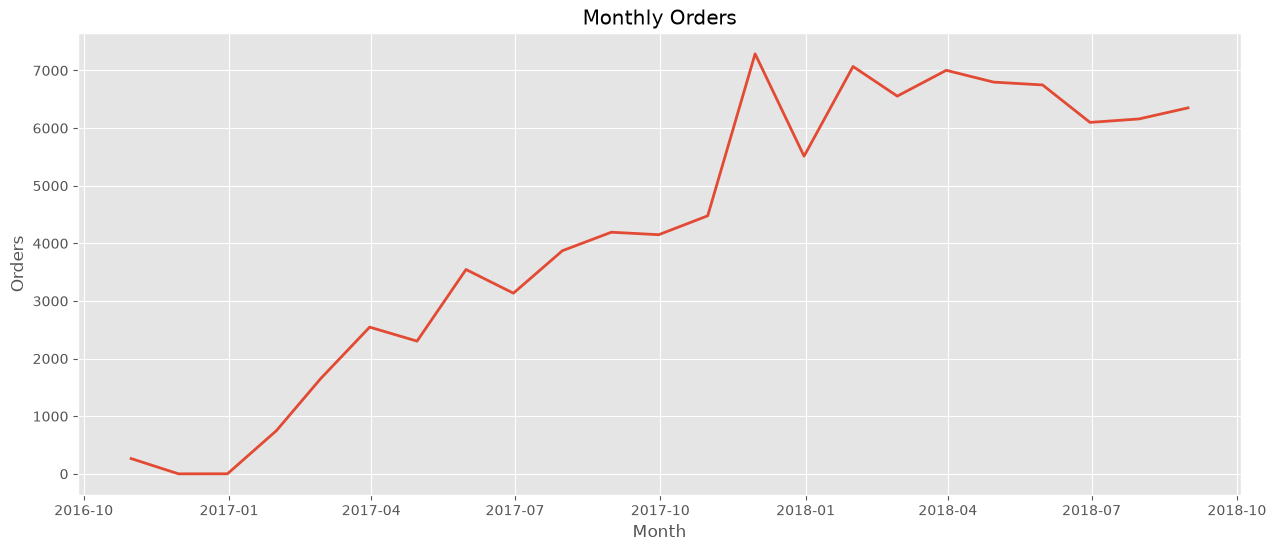

In [69]:
plt.figure(figsize=(15,6))

plt.plot(
    monthly_sales.index,
    monthly_sales["orders"],
    linewidth=2
)

plt.title("Monthly Orders")
plt.xlabel("Month")
plt.ylabel("Orders")

plt.grid(True)

plt.show()

### Dataset shape

In [70]:
print("Weekly observations :", len(weekly_sales))
print("Monthly observations:", len(monthly_sales))

Weekly observations : 100
Monthly observations: 23


#### The beginning of the series

- The period from October 2016 to January 2017 is clearly abnormal.

- Observations:

    - Several weeks have almost zero revenue.
    - Then revenue starts increasing rapidly.

This is unlikely to represent true business seasonality. It is more consistent with the marketplace launching and gradually gaining activity.

#### The end of the series

- The last week drops from around 280k to roughly 10k.

- That is almost certainly because the dataset ends before the week finishes.

- This last week should definitely be removed.

In [71]:
weekly_sales.head(20)

,revenue,orders
order_purchase_timestamp,,
2016-10-09,42669.98,231
2016-10-16,3896.73,34
2016-10-23,0.00,0
2016-10-30,0.00,0
2016-11-06,0.00,0
2016-11-13,0.00,0
2016-11-20,0.00,0
2016-11-27,0.00,0
2016-12-04,0.00,0


In [72]:
weekly_sales.tail(10)

,revenue,orders
order_purchase_timestamp,,
2018-07-01,219584.94,1382
2018-07-08,184784.27,1178
2018-07-15,180520.25,972
2018-07-22,258226.48,1649
2018-07-29,278926.28,1610
2018-08-05,320204.74,2002
2018-08-12,318700.65,1931
2018-08-19,285766.68,1839
2018-08-26,145680.87,1054


### Remove the early weeks and start from 2017-01-08 till 2018-08-26

In [73]:
START_DATE = "2017-01-08"
END_DATE = "2018-08-26"

weekly_sales = weekly_sales.loc[
    START_DATE:END_DATE
].copy()

In [74]:
print(weekly_sales.head())

print(weekly_sales.tail())

print(len(weekly_sales))

                           revenue  orders
order_purchase_timestamp                  
2017-01-08                 3651.39      44
2017-01-15                12590.09      73
2017-01-22                27209.61     189
2017-01-29                60985.50     332
2017-02-05                78392.75     432
                            revenue  orders
order_purchase_timestamp                   
2018-07-29                278926.28    1610
2018-08-05                320204.74    2002
2018-08-12                318700.65    1931
2018-08-19                285766.68    1839
2018-08-26                145680.87    1054
86


In [75]:
weekly_sales.sort_values(
    by="revenue",
    ascending=False
).head(10)

,revenue,orders
order_purchase_timestamp,,
2017-11-26,464219.77,2915
2018-05-13,334320.93,1943
2018-08-05,320204.74,2002
2018-08-12,318700.65,1931
2017-12-03,307936.11,2047
2018-03-04,295737.14,1849
2018-05-20,295686.95,1805
2018-08-19,285766.68,1839
2018-07-29,278926.28,1610


## Final Validation

In [76]:
weekly_sales.isna().sum()

revenue    0
orders     0
dtype: int64

In [77]:
weekly_sales.describe()

,revenue,orders
count,86.000000,86.000000
mean,178649.766395,1117.383721
std,84237.747342,527.545775
min,3651.390000,44.000000
25%,118006.972500,754.750000
50%,163454.890000,977.000000
75%,246507.145000,1552.500000
max,464219.770000,2915.000000


In [78]:
weekly_sales.info()

<class 'pandas.DataFrame'>
DatetimeIndex: 86 entries, 2017-01-08 to 2018-08-26
Freq: W-SUN
Data columns (total 2 columns):
 #   Column   Non-Null Count  Dtype  
---  ------   --------------  -----  
 0   revenue  86 non-null     float64
 1   orders   86 non-null     int64  
dtypes: float64(1), int64(1)
memory usage: 2.0 KB


In [79]:
weekly_sales.to_csv(
    "../../data/processed/Sales_forcasting_data/weekly_sales.csv",
    index=True
)

The weekly sales dataset was prepared by filtering completed orders, aggregating weekly revenue and order counts, removing the inactive startup period and the incomplete final week, and saving the cleaned time series for subsequent exploratory analysis and forecasting.